# 02. $p$-variation

**Question:** how well can the roughness of a path be measured from samples?

Separate from notebook 01, which estimates $\|f\|_{L^p}$, a measure of size. $p$-variation measures roughness, is not an integral, and its computation is an open algorithmic question rather than textbook quadrature.

Relevance to the project: a path of finite $p$-variation requires $\lfloor p\rfloor$ signature levels, so this quantity sets the cost of the signature work in weeks 3 to 5.

---

In [1]:
%matplotlib inline
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from pathloss.norms import p_variation_dyadic, p_variation_exact
from pathloss.paths import brownian_motion, smooth_test_path

plt.rcParams.update({"figure.figsize": (10, 3.6), "figure.dpi": 110})

## 1. Definition and standard facts

$\|f\|_{L^p}$ measures size; the $p$-variation

$$V_p(f) = \Big(\sup_{\mathcal{P}} \sum_i |f(t_{i+1}) - f(t_i)|^p\Big)^{1/p},
\qquad \mathcal{P}: 0 = t_0 < \cdots < t_m = T,$$

measures roughness. Standard facts:

- $V_p$ is non-increasing in $p$, the opposite monotonicity to $\|f\|_{L^p}$.
- $p=1$ is total variation. $V_1 < \infty$ iff Riemann-Stieltjes integration against $f$ is defined, equivalently iff bounded-variation signatures exist.
- Brownian motion has $V_p < \infty$ a.s. exactly for $p > 2$, so $p=2$ is critical and rough path theory requires level $\lfloor p\rfloor = 2$.
- The supremum runs over all partitions: a combinatorial optimisation, not a sum. Restricting to nested dyadic partitions gives a cheap lower bound; §2 quantifies the cost.

Unlike the $L^p$ case, computing $V_p$ is an open algorithmic question: Butkus & Norvaiša (2018) with the R package `pvar`, and Daoudi & Junca (2024).

Expected behaviour: as $p$ crosses the critical exponent, the dyadic estimate should change from diverging under refinement to stabilising.

    p           BM       smooth
  1.0      71.2622       8.0000
  1.5       4.0086       4.0000
  2.0       1.4447       2.8284
  2.5       1.4447       2.2974
  3.0       1.4447       2.0000


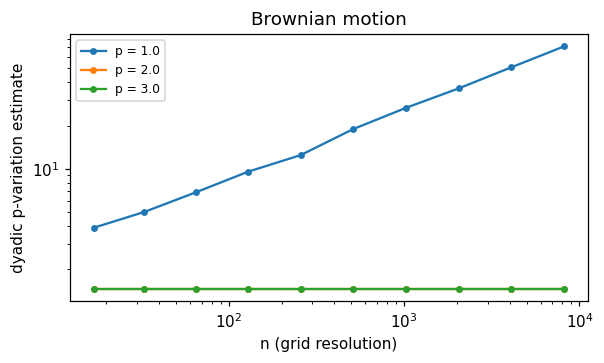

In [2]:
t_bm, Wp = brownian_motion(n=2**13 + 1, T=1.0, d=1, rng=7)
t_sm, Xs = smooth_test_path(n=2**13 + 1, freq=2.0)

print(f"{'p':>5} {'BM':>12} {'smooth':>12}")
for p in [1.0, 1.5, 2.0, 2.5, 3.0]:
    print(f"{p:>5} {p_variation_dyadic(Wp, p):>12.4f} {p_variation_dyadic(Xs, p):>12.4f}")

# refinement behaviour: does the estimate stabilise?
plt.figure(figsize=(5.6, 3.4))
for p in [1.0, 2.0, 3.0]:
    est = [p_variation_dyadic(Wp[::2**(13-k)], p) for k in range(4, 14)]
    plt.loglog([2**k + 1 for k in range(4, 14)], est, "o-", ms=3.5, label=f"p = {p}")
plt.xlabel("n (grid resolution)"); plt.ylabel("dyadic p-variation estimate")
plt.title("Brownian motion"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

$V_1$ grows without bound under refinement, Brownian paths not being of bounded variation; $V_3$ flattens; $p=2$ sits at the boundary, where the quadratic variation converges to $T$ in probability while the true 2-variation is a.s. infinite. That the dyadic estimate at $p=2$ appears convergent is a limitation of the estimator: **restricting to dyadic partitions gives a lower bound that can be badly non-tight at the critical exponent.** §2 quantifies this.

## 2. Cost of the dyadic restriction

`p_variation_dyadic` maximises over nested dyadic partitions at cost $O(n\log n)$, giving a weaker lower bound than the supremum. `p_variation_exact` optimises over all subsequences of the observed grid by dynamic programming: with $D[j]$ the largest sum ending at index $j$,

$$D[0] = 0, \qquad D[j] = \max_{i<j}\Big(D[i] + |x_j - x_i|^p\Big), \qquad V_p = D[n-1]^{1/p},$$

in $O(n^2)$ time and $O(n)$ memory. Still a lower bound on the continuous-time $V_p$, the path between samples being unobserved, but exact on the available grid.

**Why a search is required.** For $p>1$, merging increments $a, b$ of the same sign gives $|a+b|^p > |a|^p + |b|^p$, so coarsening can increase the sum and the optimal partition is not the finest. At $p=1$ equality holds, the finest partition is optimal, and $V_1$ is a cumulative sum, linear in $n$.

This is Ferrucci, Perrée & Lyons (2026, Remark 2.2): for $p=1$ an optimal split is a cumulative-sum problem and hence linear, whereas *"for the $p$-variation control with $p>1$ the analogous problem is computationally harder, since even computing the ordinary $p$-variation requires an optimisation over partitions."*

In [3]:
from pathloss.norms import p_variation_exact
import time

_, Wq = brownian_motion(n=2**9 + 1, T=1.0, d=1, rng=3)

print(f"{'p':>5} {'dyadic':>10} {'exact (DP)':>12} {'ratio':>8} {'t_dyad':>9} {'t_exact':>9}")
for p in [1.0, 1.5, 2.0, 2.5, 3.0]:
    t0 = time.perf_counter(); vd = p_variation_dyadic(Wq, p); t1 = time.perf_counter()
    ve = p_variation_exact(Wq, p); t2 = time.perf_counter()
    print(f"{p:>5} {vd:>10.4f} {ve:>12.4f} {ve/vd:>8.2f} "
          f"{t1-t0:>9.4f} {t2-t1:>9.4f}")

    p     dyadic   exact (DP)    ratio    t_dyad   t_exact
  1.0    17.8206      17.8206     1.00    0.0004    0.0044
  1.5     2.5383       3.6522     1.44    0.0001    0.0053
  2.0     1.4032       2.0784     1.48    0.0001    0.0037
  2.5     1.4032       1.8339     1.31    0.0001    0.0052
  3.0     1.4032       1.8037     1.29    0.0001    0.0052


At $p=1$ the two estimators agree, as derived. For $p>1$ the dyadic estimate understates the grid supremum by up to roughly 50%.

The dyadic value is identical at $p = 2, 2.5, 3$: the maximising dyadic partition has collapsed to $[0,T]$, returning $|W_T - W_0|$ for every $p$.

**Rule adopted.** Quote $p$-variation from the exact dynamic program for $n \lesssim 4000$; treat the dyadic value as a screening statistic. A claim that a path has finite $p$-variation for $p > p_0$ based on the dyadic estimate reports a lower bound as a measurement.

---

---

## References

Keyed to `papers/references.bib`.

- ★ **Ferrucci, Perrée & Lyons (2026)**, arXiv:2607.26281, Remark 2.2: why $V_p$ for $p>1$ requires an optimisation over partitions. §2.
- **Butkus & Norvaiša (2018)**, *Computation of p-variation*, Lith. Math. J. 58, with R package `pvar`. §1, §2.
- **Daoudi & Junca (2024)**, *Efficient algorithms computing p-variation*, preprint. §1.